1. Pré-processamento
2. Dataset usado: https://www.kaggle.com/datasets/saurabhshahane/fake-news-classification
0 é fake e 1 é real

In [3]:
import pandas as pd
import sklearn as sk
from numpy.ma.extras import average

# Exibe a versão da pandas e sklearn
pd.__version__, sk.__version__

('3.0.0', '1.8.0')

Lê a base de dados e a exibe

In [4]:
CAMINHO = "C:\\Users\\Nitro\\Desktop\\Redes-Neurais\\archive\\WELFake_Dataset.csv"

df = pd.read_csv(CAMINHO)

# Exibe as primeiras linhas do Dataframe
df.head()

,Unnamed: 0,title,text,label
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,1,NaN,Did they post their votes for Hillary already?,1
2,2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1


Remove a primeira coluna do dataframe

In [5]:
# A função "drop" remove uma coluna (ou linha) de um Dataframe
# "df.columns[0]" seleciona a primeira coluna do Dataframe
# "axis=1" especifica que queremos remover uma coluna, não uma linha (o valor 1 significa coluna, enquanto o valor 0 significa linha)

df = df.drop(df.columns[0], axis=1)
# A remoção não afeta o Dataframe original, então atribuímos o resultado de volta ao "df"

In [6]:
# Exibe as primeiras linhas do Dataframe
df.head()

,title,text,label
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,NaN,Did they post their votes for Hillary already?,1
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1


Remove linhas nulas

In [7]:
# total de linhas do dataframe
df.shape[0]

72134

In [8]:
# O método "isnull()" verifica quais valores do Dataframe são nulos e retorna um Dataframe de valores booleanos com a mesma forma
# O método "sum()" soma os valores booleanos em cada coluna, contando quantos valores nulos existem

df.isnull().sum()

title    558
text      39
label      0
dtype: int64

In [9]:
# Remove linhas nulas
df = df.dropna()

#exibe de novo pra gente conferir o que mudou
df.isnull().sum()

title    0
text     0
label    0
dtype: int64

In [10]:
# total de linhas do dataframe
df.shape[0]

71537

Checa e remove linhas repetidas

In [11]:
# Encontra as linhas duplicadas usando o método "duplicated"
df.duplicated().sum()

np.int64(8416)

In [12]:
# Remove as linhas duplicadas usando o método "drop_duplicates"
df = df.drop_duplicates()

#mostra o total de linhas na base de dados agora
df.shape[0]

63121

Existe equilíbrio no dataset?

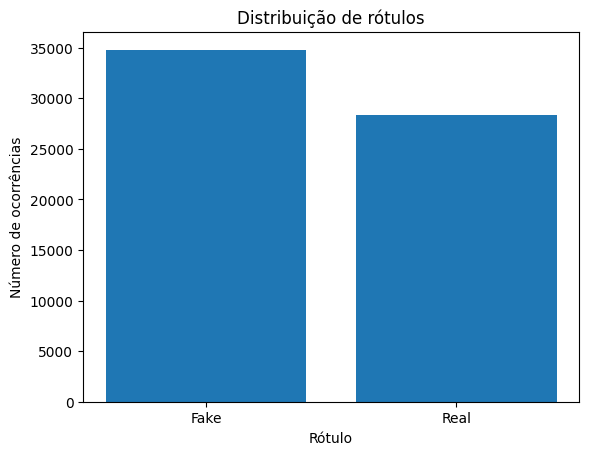

In [13]:
import matplotlib.pyplot as plt

#Conta o número de ocorrências de cada rótulo
label_count = df.label.value_counts()

# Cria um gráfico de barras usando a Matplotlib
plt.bar(label_count.index, label_count)

# Define o título do gráfico
plt.title("Distribuição de rótulos")

# Define o nome do eixo x do gráfico
plt.xlabel("Rótulo")

# Define o nome do eixo y do gráfico
plt.ylabel("Número de ocorrências")

# Mostrar os rótulos corretamente no eixo x
plt.xticks([0,1], ["Fake", "Real"])

# Exibe o gráfico
plt.show()

In [14]:
print("Totaç de rótulos Fake:", 100* label_count[0]/(label_count[0] + label_count[1]))
print("Total de rótulos Real:", 100*label_count[1] / (label_count[0] + label_count[1]))

# há um desbalanceamento aqui, que pode ser tratado com sobreamostragem, subamostragem dentre outras técnicas

Totaç de rótulos Fake: 55.11794806799639
Total de rótulos Real: 44.88205193200361


2. TF-IDF
3. Bag-of-words é uma abordagem simples para representar texto como um conjunto de características (features) ou tokens que podem ser usados em modelos de aprendizado de máquina. Apesar de ser amplamente utilizado e eficaz em muitos casos, ele tem algumas desvantagens:

Trata cada palavra como independente e ignora o contexto em que as palavras aparecem. Isso pode levar a resultados ruins ao lidar com frases ou expressões.

Ele trata todas as palavras igualmente (peso igual), mesmo que algumas palavras possam ser mais informativas ou discriminativas do que outras.

Ele pode ser sensível a ruídos e pontos fora da curva, já que não distingue entre palavras informativas e menos informativas.

O TF-IDF (term frequency-inverse document frequency) lida com essas desvantagens. Ele atribui um peso a cada palavra em um documento baseado em sua frequência e raridade no corpus de documentos. Especificamente, o TF-IDF é calculado como o produto de dois valores:

Frequência do termo (TF): quantas vezes o termo aparece em cada documento?

Frequência inversa do documento (IDF): uma medida de quão raro um termo é no corpus de documentos. Se um termo aparece pouco, então ele é mais informativo e acaba tendo mais peso. A ideia da fórmula é fazer com que caso um termo apareça muito ao longo de vários documentos, então esse valor precisa ser baixo.
O peso TF-IDF para um termo em um documento é o produto de seus valores TF e IDF. Atribuindo pesos mais altos a termos informativos e raros, o TF-IDF pode superar as desvantagens do modelo bag-of-words.

Frequência do Termo (TF): é o número de vezes em que um termo aparece em um documento. É calculado como:
TF(t, d) = (número de vezes que o termo t aparece no documento d) / (número total de termos no documento d),

onde t é o termo e d é o documento.

Frequência Inversa do Documento (IDF): mede a raridade de um termo em todos os documentos em um corpus. Se o termo for comum, seu valor se aproxima de 0. Caso contrário, se aproxima de 1. É calculado como:
IDF(t) = log_e(Número total de documentos / Número de documentos com o termo t)

onde t é o termo e o logaritmo natural (log base e) é usado para reduzir o efeito da pontuação IDF para termos muito frequentes.

TF-IDF: a pontuação TF-IDF de um termo em um documento é o produto de sua pontuação TF e pontuação IDF. É calculado como:
TF-IDF(t, d) = TF(t, d) * IDF(t)
onde t é o termo e d é o documento.

In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer #vetoriza usando TF-IDF

#juntamos título e texto na mesma coluna
# axis = 1 é concatenação horizontal
#lambda: para cada linha, aplicamos a união de title e text, incluindo um espaço entre os dois
df['news'] = pd.concat([df["title"], df["text"]], axis=1).apply(lambda x: " ".join(x), axis=1)

df.head()

,title,text,label,news
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1,LAW ENFORCEMENT ON HIGH ALERT Following Threat...
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...
3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0,"Bobby Jindal, raised Hindu, uses story of Chri..."
4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1,SATAN 2: Russia unvelis an image of its terrif...
5,About Time! Christian Group Sues Amazon and SP...,All we can say on this one is it s about time ...,1,About Time! Christian Group Sues Amazon and SP...


Alguns tratamentos como remoção de stopwords, lemmatização...

In [17]:
import nltk
from nltk.corpus import stopwords

'''nltk.download('stopwords')'''

# Remove as palavras de parada (stop words) de cada notícia
stop_words = set(stopwords.words('english'))
df["news_no_stopwords"] = df["news"].apply(lambda x: " ".join([word for word in x.split() if word not in stop_words]))

df['news_no_stopwords']

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Nitro\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


0        LAW ENFORCEMENT ON HIGH ALERT Following Threat...
2        UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...
3        Bobby Jindal, raised Hindu, uses story Christi...
4        SATAN 2: Russia unvelis image terrifying new ‘...
5        About Time! Christian Group Sues Amazon SPLC D...
                               ...                        
72127    WIKILEAKS EMAIL SHOWS CLINTON FOUNDATION FUNDS...
72129    Russians steal research Trump hack U.S. Democr...
72130    WATCH: Giuliani Demands That Democrats Apologi...
72131    Migrants Refuse To Leave Train At Refugee Camp...
72132    Trump tussle gives unpopular Mexican leader mu...
Name: news_no_stopwords, Length: 63121, dtype: str

In [18]:
#total de palavras ANTES das stopwords

df['news'].str.split().apply(len)

0         889
2          52
3        1337
4         345
5         257
         ... 
72127     220
72129     746
72130     614
72131     487
72132     569
Name: news, Length: 63121, dtype: int64

In [19]:
#total de palavras DEPOIS das stopwords
df['news_no_stopwords'].str.split().apply(len)

0        541
2         40
3        810
4        233
5        162
        ... 
72127    145
72129    493
72130    353
72131    297
72132    366
Name: news_no_stopwords, Length: 63121, dtype: int64

In [21]:
from nltk.stem import WordNetLemmatizer
'''nltk.download('wordnet')'''

# Reduz as palavras em cada notícia para sua forma canônica (lemmatization)
lemmatizer = WordNetLemmatizer()
df['news_lemmatized'] = df['news_no_stopwords'].apply(lambda x: ' '.join([lemmatizer.lemmatize(word) for word in x.split()]))


[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Nitro\AppData\Roaming\nltk_data...


In [22]:
from sklearn.model_selection import train_test_split

# Separa o conjunto de dados em conjuntos de treinamento e teste
X_train, X_test, y_train, y_test = train_test_split(df['news_no_stopwords'], df['label'], test_size=0.2)

In [23]:
#Vetoriza os dados de texto usando TF-IDF
tfidf_vectorizer = TfidfVectorizer()
trains_features = tfidf_vectorizer.fit_transform(X_train)
test_features = tfidf_vectorizer.transform(X_test)

In [24]:
from sklearn.naive_bayes import MultinomialNB

# Cria um modelo de classificação Naive Bayes Multinomial e o treina com os dados de treinamento

clf = MultinomialNB()
clf.fit(trains_features, y_train)

# Avalia a acurácia do modelo nos dados de treino
accuracy = clf.score(trains_features, y_train)
print("Acurácia:", accuracy)

Acurácia: 0.8766634980988594


In [25]:
# Avalia a acurácia do modelo nos dados de teste
accuracy = clf.score(test_features, y_test)
print("Acurácia:", accuracy)

Acurácia: 0.858059405940594


In [26]:
from sklearn.metrics import classification_report

# faz a predição no conjunto de teste
y_pred = clf.predict(test_features)

# calcula as métricas de classificação
report = classification_report(y_test, y_pred, target_names=["Fake", "Real"])

# imprime o relatório
print(report)

              precision    recall  f1-score   support

        Fake       0.82      0.94      0.88      6952
        Real       0.91      0.75      0.83      5673

    accuracy                           0.86     12625
   macro avg       0.87      0.85      0.85     12625
weighted avg       0.87      0.86      0.86     12625



Precision:
a proporção de verdadeiros positivos (TP) entre o total de resultados classificados como positivos (TP + FP). No caso de notícias falsas, a precisão é de 0.82, ou seja, 82% das notícias classificadas como falsas pelo modelo realmente são falsas. Para notícias verdadeiras, a precisão é de 0.92, ou seja, 92% das notícias classificadas como verdadeiras pelo modelo realmente são verdadeiras.

TP = Notícias verdadeiras classificadas como verdadeiras
FP = Fake news classificadas incorretamente como verdadeiras
Recall:
a proporção de verdadeiros positivos (TP) entre o total de exemplos positivos (TP + FN). No caso de notícias falsas, o recall é de 0.94, ou seja, o modelo consegue detectar 94% das notícias falsas presentes no conjunto de dados. Para notícias verdadeiras, o recall é de 0.74, ou seja, o modelo consegue detectar apenas 74% das notícias verdadeiras presentes no conjunto de dados.

FN = Notícias verdadeiras classificadas incorretamente como fake
F1-score:
medida que combina precisão e recall, permitindo avaliar o desempenho de um modelo de classificação em relação às duas classes (verdadeiro e falso, neste caso).

Um valor de F1-score de 0.82 para notícias verdadeiras significa que o modelo tem um bom equilíbrio entre precisão e recall na classificação de notícias verdadeiras. Isso indica que o modelo é capaz de identificar corretamente a maioria das notícias verdadeiras, enquanto minimiza o número de falsos negativos.

Já um valor de F1-score de 0.88 para notícias falsas indica um desempenho um pouco melhor na classificação de notícias falsas em comparação com as verdadeiras. Isso pode ser interpretado como uma maior capacidade do modelo em identificar notícias falsas, enquanto ainda consegue minimizar o número de falsos positivos.

Cross Validation

In [28]:
from sklearn.model_selection import cross_validate
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score

# Recria o classificador
clf = MultinomialNB()

# Define as métricas que deseja calcular
scoring = {
    'accuracy': make_scorer(accuracy_score),
    'precision_0': make_scorer(precision_score, average='binary', pos_label=0),
    'recall_0': make_scorer(recall_score, average='binary', pos_label=0),
    'f1_score_0': make_scorer(f1_score, average='binary', pos_label=0),
    'precision_1': make_scorer(precision_score, average='binary', pos_label=1),
    'recall_1': make_scorer(recall_score, average='binary', pos_label=1),
    'f1_score_1': make_scorer(f1_score, average='binary', pos_label=1)
}

# Aplica a validação cruzada e calcula as métricas para cada fold
scores = cross_validate(clf, trains_features, y_train, cv=5, scoring=scoring)

# Imprime as métricas médias e desvio padrão para cada fold
print("Métricas para a classe 0:")
print("Acurácia média:", scores['test_accuracy'].mean())
print("Precisão média:", scores['test_precision_0'].mean())
print("Recall médio:", scores['test_recall_0'].mean())
print("F1-score médio:", scores['test_f1_score_0'].mean())

print("\nMétricas para a classe 1:")
print("Acurácia média:", scores['test_accuracy'].mean())
print("Precisão média:", scores['test_precision_1'].mean())
print("Recall médio:", scores['test_recall_1'].mean())
print("F1-score médio:", scores['test_f1_score_1'].mean())

Métricas para a classe 0:
Acurácia média: 0.8527209438440625
Precisão média: 0.8152747514656026
Recall médio: 0.9475916616081218
F1-score médio: 0.8764600445418393

Métricas para a classe 1:
Acurácia média: 0.8527209438440625
Precisão média: 0.9195756223034015
Recall médio: 0.7361522554344174
F1-score médio: 0.817682073827392


Referências
ChatGPT
https://www.udemy.com/course/natural-language-processing-in-python/
https://www.youtube.com/watch?v=5MaWmXwxFNQ
https://www.youtube.com/watch?v=ATK6fm3cYfI&list=PLeo1K3hjS3uuvuAXhYjV2lMEShq2UYSwX&index=18
https://en.wikipedia.org/wiki/Precision_and_recall
https://scikit-learn.org/stable/modules/generated/sklearn.metrics.make_scorer.html